In [14]:
import pandas as pd
import numpy as np
import math
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay

mpl.rcParams['figure.figsize'] = (15.0, 6.0)
pd.set_option('display.max_columns', 30)

## Dataset Overview

In [15]:
# Read the preprocessed dataset
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
offers_df = pd.read_csv(DATA_DIR / 'processed' / 'preprocessed_data.csv')
offers_df.head()

,person,offer,offer_completed,age,income,reward,difficulty,duration,days_since_registration,web,email,mobile,social,gender_M,gender_O,offer_type_discount
0,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,33.0,72000.0,5,5,5,461,1,1,1,1,True,False,False
1,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,33.0,72000.0,2,10,10,461,1,1,1,1,True,False,True
2,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,False,NaN,NaN,5,5,5,92,1,1,1,1,False,False,False
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,True,40.0,57000.0,5,20,10,198,1,1,0,0,False,True,True
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,True,40.0,57000.0,3,7,7,198,1,1,1,1,False,True,True


## Model Comparison

In [16]:
# Create train test split
X = offers_df.drop(['person', 'offer', 'offer_completed'], axis=1)
y = offers_df['offer_completed']
X_train, X_test, y_train, y_test = train_test_split(X, y)
print("Train set shape", X_train.shape)
print("Test set shape", X_test.shape)

Train set shape (29869, 13)
Test set shape (9957, 13)


In [17]:
# Impute missing values and standardize features
trans_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_train = pd.DataFrame(trans_pipe.fit_transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(trans_pipe.transform(X_test), columns = X_train.columns)

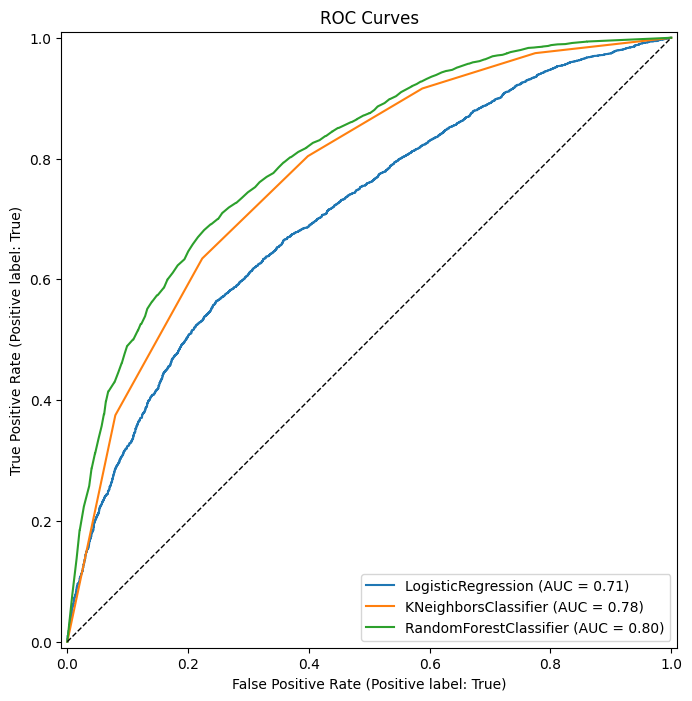

In [18]:
# Compare classifiers
models = [LogisticRegression(), KNeighborsClassifier(), RandomForestClassifier()]

fig, ax = plt.subplots(figsize=(8,8))
ax.set_title("ROC Curves")
for model in models:
    model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
plt.plot([0,1], [0,1], 'black', lw=1, ls='--')
plt.show()

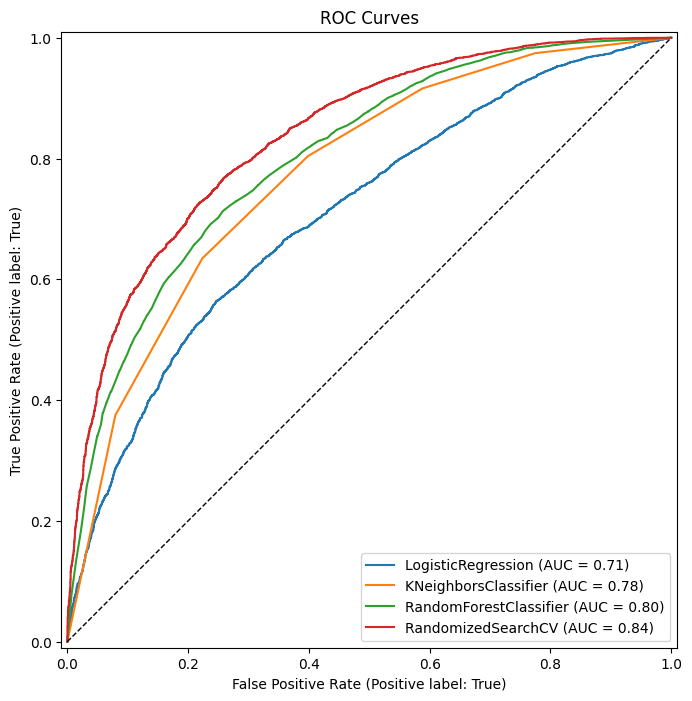

In [19]:
# Tune random forest classifier (reduced search space for practical notebook runtime)
params = {'bootstrap': [True, False],
          'max_depth': [10, 20, 30, None],
          'max_features': ['sqrt', 'log2'],
          'min_samples_leaf': [1, 2, 4],
          'min_samples_split': [2, 5, 10],
          'n_estimators': [200, 400, 600]}

cv = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=params,
    n_iter=8,
    cv=3,
    random_state=42,
    n_jobs=-1
 )

models = [
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(),
    RandomForestClassifier(random_state=42),
    cv
]

fig, ax = plt.subplots(figsize=(8,8))
ax.set_title("ROC Curves")
for model in models:
    model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
plt.plot([0,1], [0,1], 'black', lw=1, ls='--')
plt.show()